In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os 
import seaborn as sns

/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [31]:
data_path = '../../Smart attack Algorithm/data/Car Hacking Dataset/'
benign_data_path = os.path.join(data_path, 'benign_data.csv')
attack_data_path = os.path.join(data_path, 'DoS_dataset.csv')
perturbed_data_path = 'Adversarial_traffic_Both_transformed.csv'

In [ ]:
benign_data = pd.read_csv(benign_data_path)
benign_data = benign_data.assign(IAT=benign_data['Timestamp'].diff().fillna(0))

In [6]:
def calculate_periodicity(df):
    # Initialize an empty dictionary to store the periodicity for each can_id
    periodicity_dict = {}

    # Group the DataFrame by 'can_id'
    grouped = df.groupby('ID')

    for can_id, group_df in grouped:
        # Sort the DataFrame by 'timestamp'
        sorted_df = group_df.sort_values(by='Timestamp')

        # Calculate the periodicity for the current can_id
        first_timestamp = sorted_df.iloc[0]['Timestamp']
        last_timestamp = sorted_df.iloc[-1]['Timestamp']
        num_occurrences = len(sorted_df)

        if num_occurrences > 1:
            periodicity = (last_timestamp - first_timestamp) / (num_occurrences - 1)
        else:
            periodicity = 0  # Avoid division by zero if there's only one occurrence

        # Store the periodicity in the dictionary
        periodicity_dict[can_id] = periodicity

    return periodicity_dict

In [7]:
benign_periodicity_dict = calculate_periodicity(benign_data)

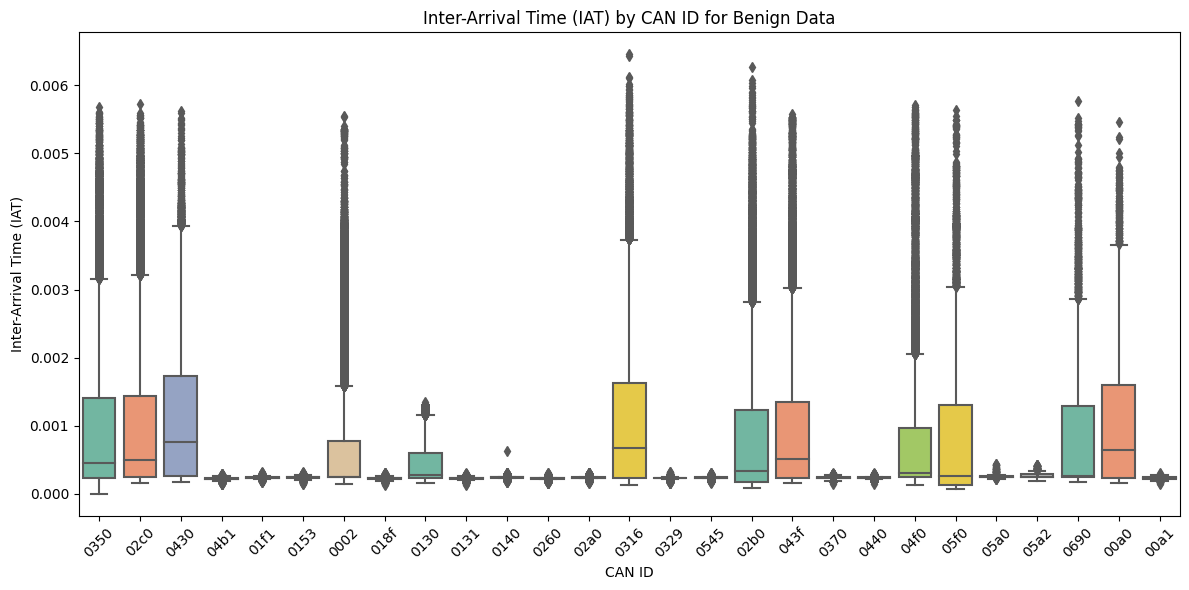

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='ID', y='IAT', data=benign_data, palette='Set2')
plt.title('Inter-Arrival Time (IAT) by CAN ID for Benign Data')
plt.xlabel('CAN ID')
plt.ylabel('Inter-Arrival Time (IAT)')
plt.xticks(rotation=45)
plt.tight_layout()


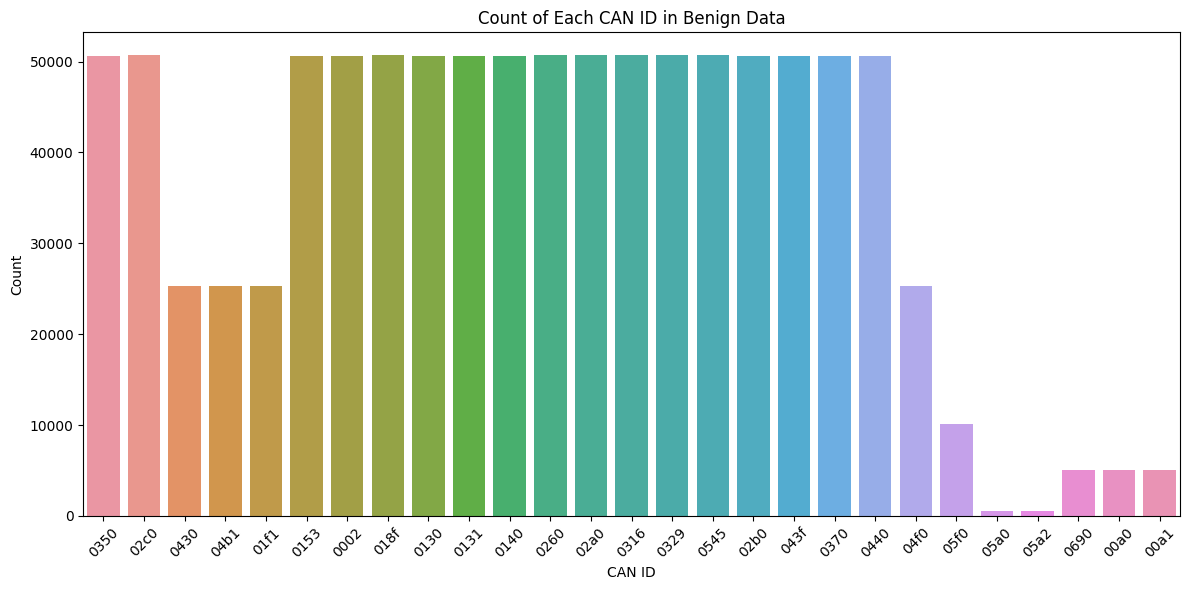

In [11]:
##Plot count of each ID in benign data
plt.figure(figsize=(12, 6))
sns.countplot(x='ID', data=benign_data)
plt.title('Count of Each CAN ID in Benign Data')
plt.xlabel('CAN ID')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()


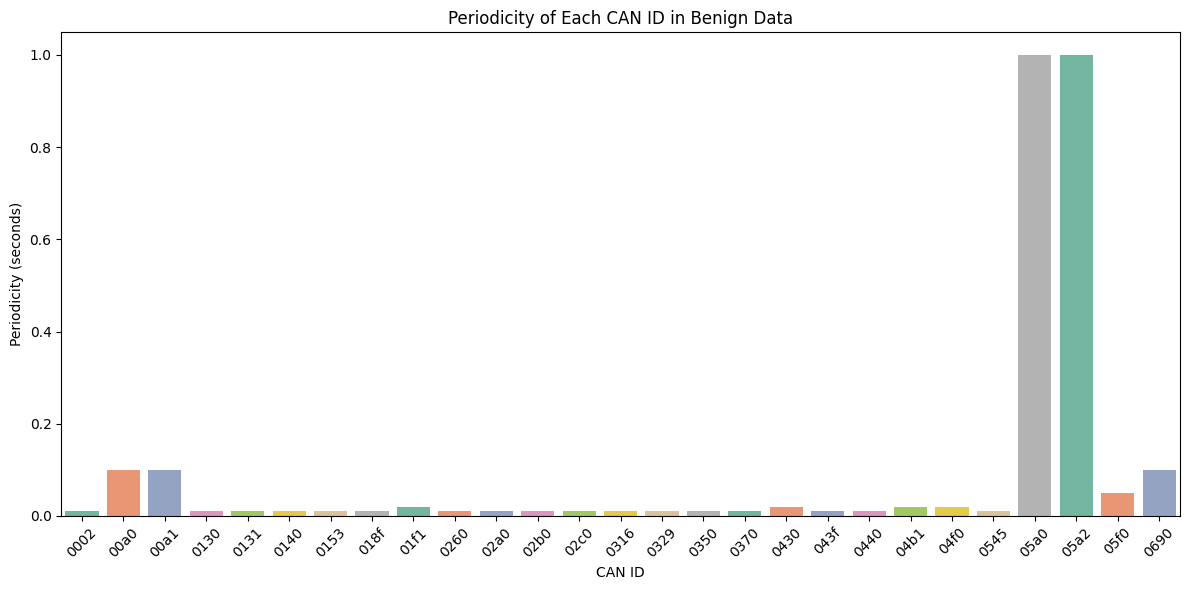

In [12]:
##Plot periodicity of each ID in benign data
periodicity_df = pd.DataFrame(list(benign_periodicity_dict.items()), columns=['ID', 'Periodicity'])
plt.figure(figsize=(12, 6))
sns.barplot(x='ID', y='Periodicity', data=periodicity_df, palette='Set2')
plt.title('Periodicity of Each CAN ID in Benign Data')
plt.xlabel('CAN ID')
plt.ylabel('Periodicity (seconds)')
plt.xticks(rotation=45)
plt.tight_layout()

In [15]:
def shift_columns(df):
    
    for dlc in [2,5,6]:

        df.loc[df['DLC'] == dlc, df.columns[3:]] = df.loc[df['DLC'] == dlc, df.columns[3:]].shift(periods=8-dlc, axis='columns', fill_value='00')

    return df
    

def read_ch_data(data_path):
    
    columns = ['Timestamp','ID', 'DLC', 'data0', 'data1', 'data2', 'data3', 'data4', 
           'data5', 'data6', 'data7', 'label']
    
    data = pd.read_csv(data_path, names = columns)

    data = shift_columns(data)
    
    ##Replacing all NaNs with '00' 
    data = data.replace(np.NaN, '00')
    
    ##Joining all data columns to put all data in one column
    data_cols = ['data0', 'data1', 'data2', 'data3', 'data4', 'data5', 'data6', 'data7']
    
    ##The data column is in hexadecimal
    data['Payload'] = data[data_cols].apply(''.join, axis=1)
    data.drop(columns = data_cols, inplace = True, axis = 1)
        
    data = data.assign(IAT=data['Timestamp'].diff().fillna(0))
    data = data[['Timestamp', 'ID','DLC','Payload', 'IAT', 'label']]
    data['label'].replace({'R' : 0, 'T' : 1}, inplace = True)
    
    return data

dos_data = read_ch_data(attack_data_path)
dos_data.head()

/var/folders/pw/3vr89zzj1xvbzvtk1yfz9kkc0000gn/T/ipykernel_6835/2211184297.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['label'].replace({'R' : 0, 'T' : 1}, inplace = True)
/var/folders/pw/3vr89zzj1xvbzvtk1yfz9kkc0000gn/T/ipykernel_6835/2211184297.py:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasti

,Timestamp,ID,DLC,Payload,IAT,label
0,1.478198e+09,0316,8,052168092121006f,0.000000,0
1,1.478198e+09,018f,8,fe5b0000003c0000,0.000209,0
2,1.478198e+09,0260,8,19212230088e6d3a,0.000228,0
3,1.478198e+09,02a0,8,64009a1d9702bd00,0.000232,0
4,1.478198e+09,0329,8,40bb7f1411200014,0.000237,0


In [16]:
dos_periodicity_dict = calculate_periodicity(dos_data)

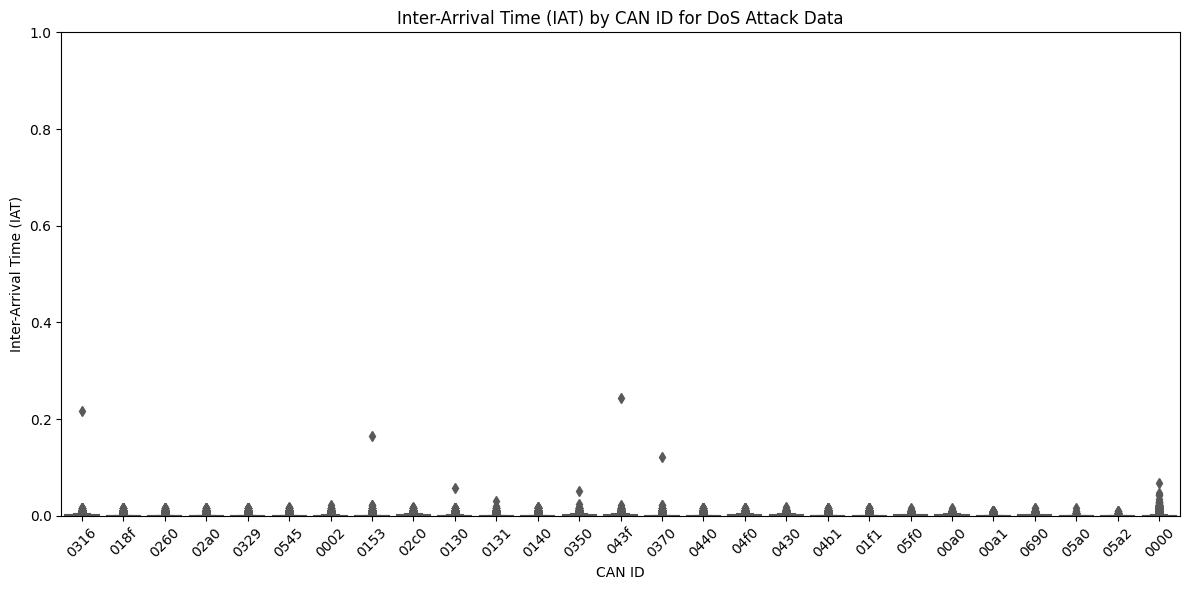

In [23]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='ID', y='IAT', data=dos_data, palette='Set2')
plt.title('Inter-Arrival Time (IAT) by CAN ID for DoS Attack Data')
plt.xlabel('CAN ID')
plt.ylabel('Inter-Arrival Time (IAT)')
plt.ylim(0,1)
plt.xticks(rotation=45)
plt.tight_layout()

In [24]:
def split_into_windows(df, window_size):
    """
    Split dataset into windows of a given size and assign a label to each window.
    
    Args:
        df (pd.DataFrame): Input dataframe.
        window_size (float): Window size in seconds.
        
    Returns:
        list: List of windowed dataframes.
        list: List of labels for each window (1 if any data point in the window is 1, else 0).
        int: Number of windows.
    """
    start_time = df['Timestamp'].min()
    end_time = df['Timestamp'].max()
    
    windows = []
    window_labels = []  # To store the label for each window
    current_time = start_time
    
    while current_time <= end_time:
        # Extract data for the current window
        window = df[(df['Timestamp'] >= current_time) & 
                    (df['Timestamp'] < current_time + window_size)]
        
        if not window.empty:
            windows.append(window)
            
            # Assign window label: 1 if any label is 1 in the window, else 0
            if (window['label'] == 1).any():
                window_labels.append(1)
            else:
                window_labels.append(0)
        
        # Move to next window
        current_time += window_size
    
    return windows, window_labels, len(windows)

def calculate_entropy(windows):
    """
    Calculate entropy for each window.
    
    Args:
        windows (list): List of windowed dataframes.
        
    Returns:
        list: List of entropy values for each window.
    """
    entropies = []
    
    for window in windows:
        # Count unique combinations of Identifier, Data Length Code, and Data
        counts = window.groupby(['ID', 'DLC', 'Payload']).size()
        total = counts.sum()
        
        if total > 0:
            # Compute probability
            probabilities = counts / total
            
            # Calculate entropy using the definition
            entropy = -np.sum(probabilities * np.log2(probabilities))
            entropies.append(entropy)
    
    return entropies

In [26]:
# window_sizes = [0.032768, 0.1, 0.5, 1] 

window_sizes = [0.1, 0.5, 1] 

clean_entropy_dict = {}  # Dictionary to store entropy values by window size
clean_window_labels_dict = {}  # Stores window labels by window size

dos_entropy_dict = {}  
dos_window_labels_dict = {}  


for window_size in window_sizes:

    train_windows, train_window_labels, train_num_windows = split_into_windows(benign_data, window_size)
    train_entropies = calculate_entropy(train_windows)
    
    # Store entropy values in dictionary
    clean_entropy_dict[window_size] = train_entropies
    clean_window_labels_dict[window_size] = train_window_labels
    
    print(f"Window size: {window_size} seconds")
    print(f"Number of training windows: {train_num_windows}")
    print(f"Average entropy: {np.mean(train_entropies):.4f}\n")

    ##Repeat the same for benign_data_val

    val_windows, val_window_labels, val_num_windows = split_into_windows(dos_data, window_size)
    val_entropies = calculate_entropy(val_windows)

    dos_entropy_dict[window_size] = val_entropies
    dos_window_labels_dict[window_size] = val_window_labels

    print(f"Window size: {window_size} seconds")
    print(f"Number of testing windows: {val_num_windows}")
    print(f"Average entropy: {np.mean(val_entropies):.4f}\n")

Window size: 0.1 seconds
Number of training windows: 5065
Average entropy: 6.4283

Window size: 0.1 seconds
Number of testing windows: 28101
Average entropy: 4.5192

Window size: 0.5 seconds
Number of training windows: 1013
Average entropy: 7.7540

Window size: 0.5 seconds
Number of testing windows: 5622
Average entropy: 5.3873

Window size: 1 seconds
Number of training windows: 507
Average entropy: 8.3134

Window size: 1 seconds
Number of testing windows: 2811
Average entropy: 5.7464



/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


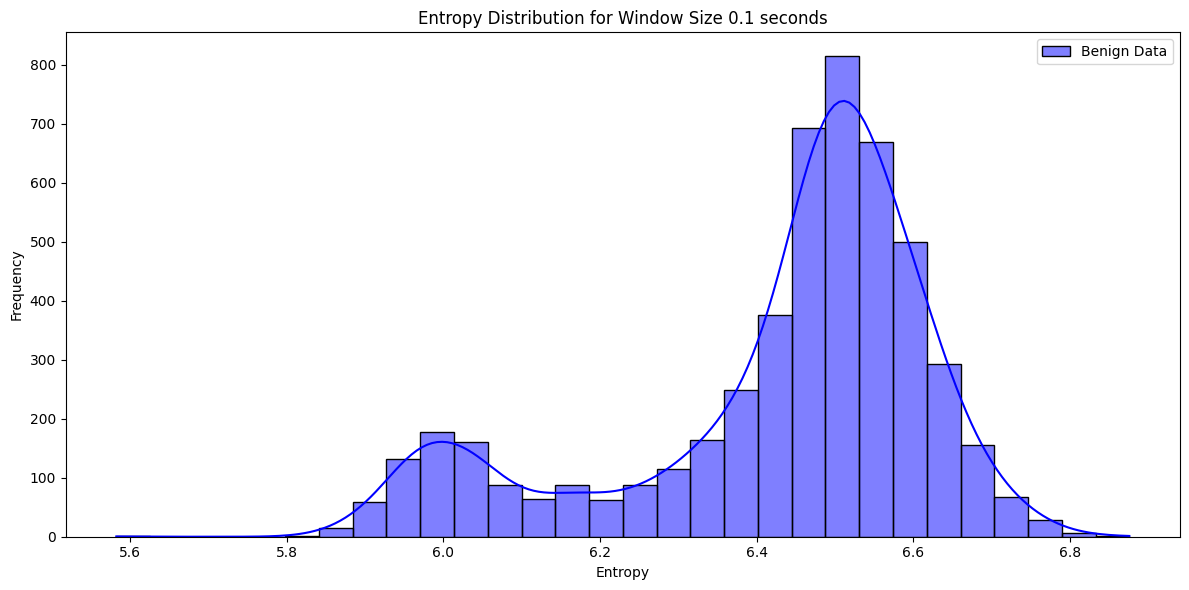

/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


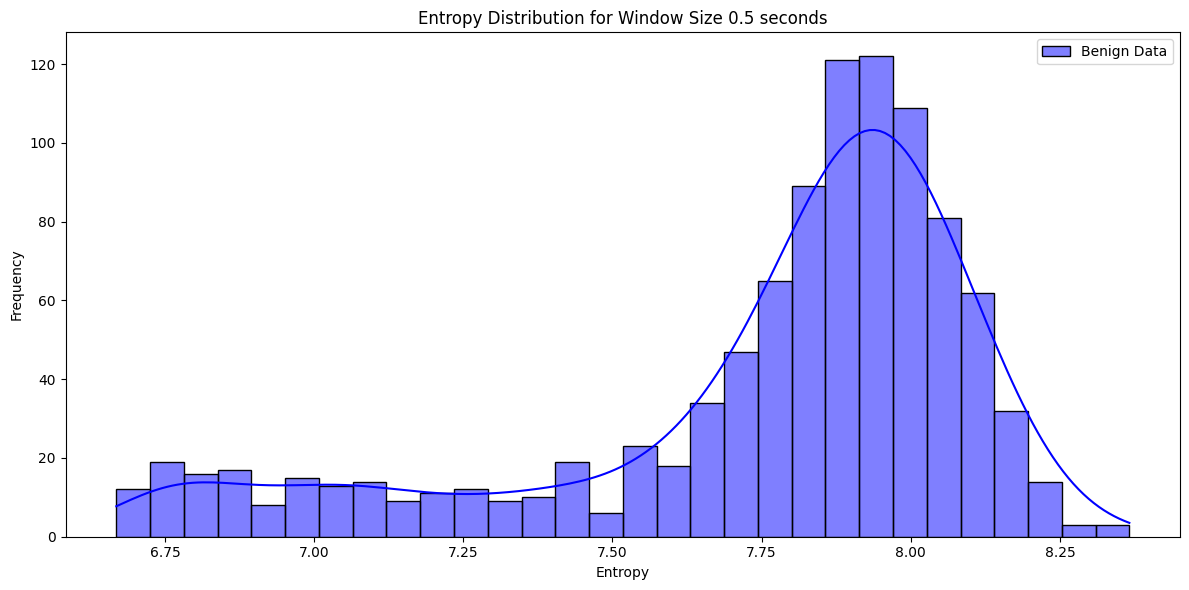

/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


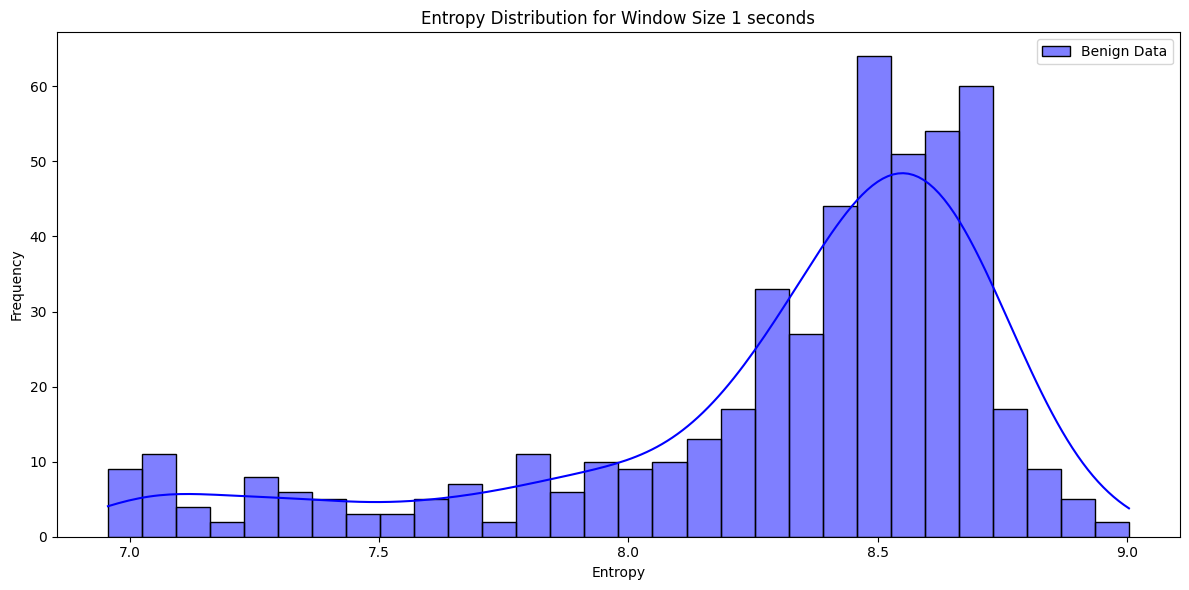

In [28]:
##Create a distplot of entropy values of each window size for benign_data

for window_size in window_sizes:
    plt.figure(figsize=(12, 6))
    sns.histplot(clean_entropy_dict[window_size], bins=30, kde=True, color='blue', label='Benign Data')
    
    plt.title(f'Entropy Distribution for Window Size {window_size} seconds')
    plt.xlabel('Entropy')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()

/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


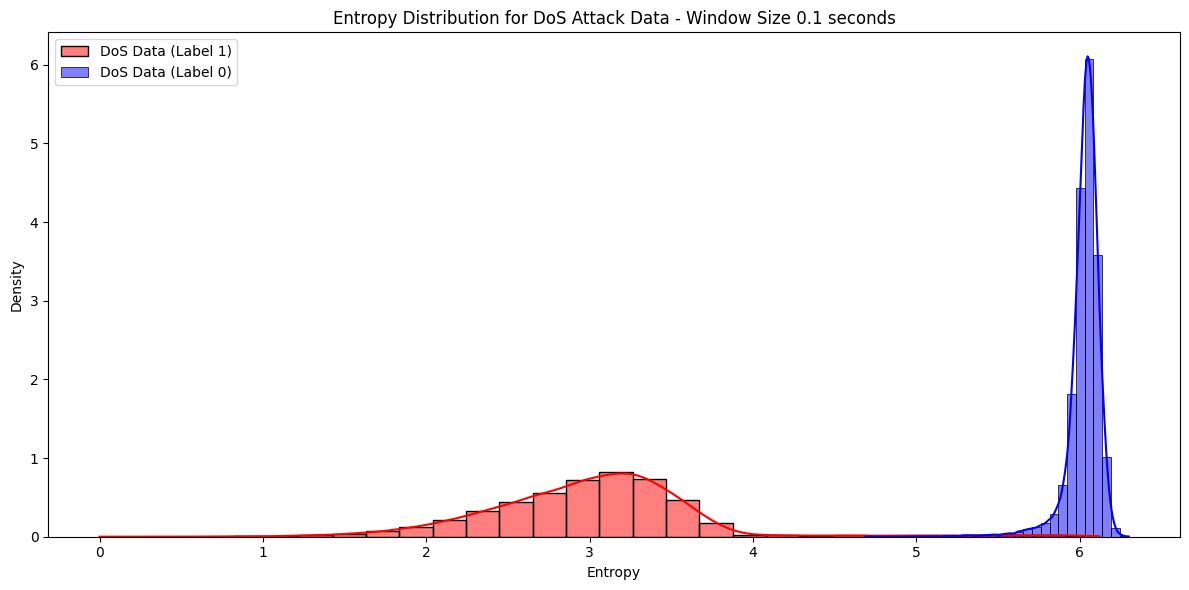

/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


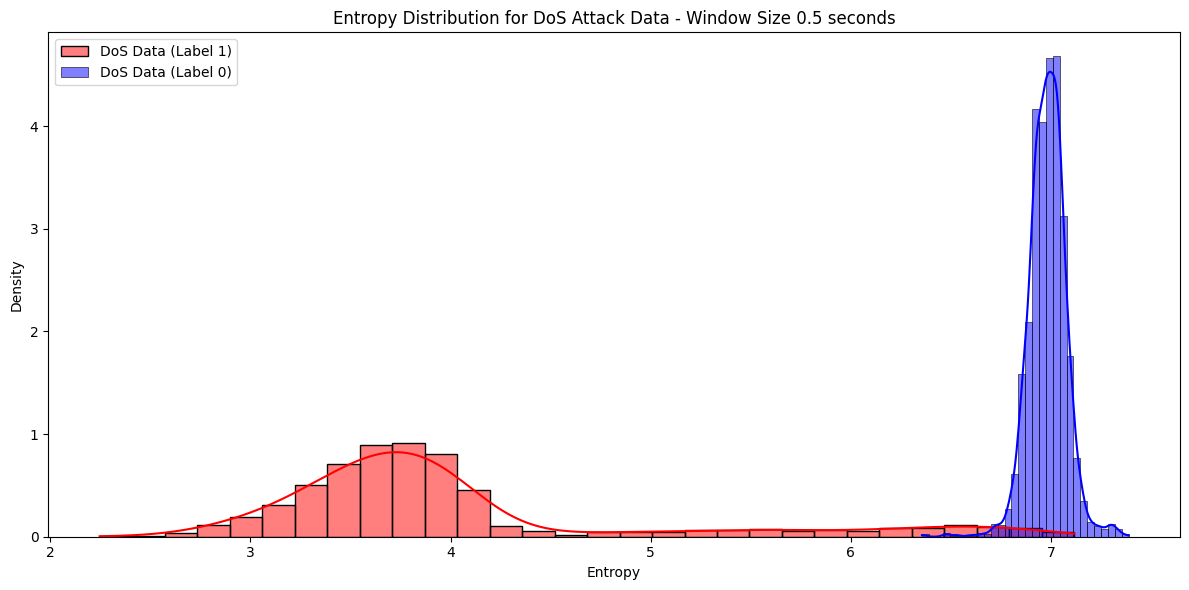

/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/anwesh/opt/anaconda3/envs/tf/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


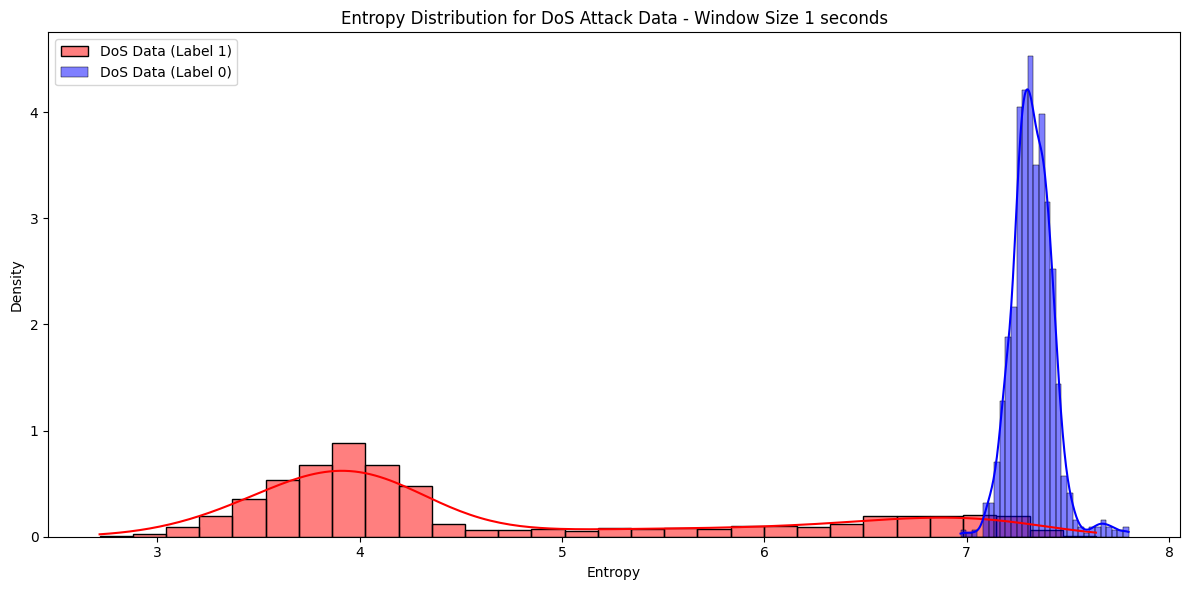

In [30]:
##Plot the entropy values of each window size for dos_data, the entropy of windows with label 1 should be in red and label 0 should be in blue
for window_size in window_sizes:
    plt.figure(figsize=(12, 6))
    
    # Plot entropy values for windows with label 1
    sns.histplot([entropy for entropy, label in zip(dos_entropy_dict[window_size], dos_window_labels_dict[window_size]) if label == 1],
                 bins=30, kde=True, color='red', label='DoS Data (Label 1)', stat='density')
    
    # Plot entropy values for windows with label 0
    sns.histplot([entropy for entropy, label in zip(dos_entropy_dict[window_size], dos_window_labels_dict[window_size]) if label == 0],
                 bins=30, kde=True, color='blue', label='DoS Data (Label 0)', stat='density')
    
    plt.title(f'Entropy Distribution for DoS Attack Data - Window Size {window_size} seconds')
    plt.xlabel('Entropy')
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [32]:
perturbed_data = pd.read_csv(perturbed_data_path)

In [ ]:
perturbed_traffic_dict = {}
peturebd_window_labels_dict = {}
perturbed_entropy_dict = {}

for window_size in window_sizes:

    train_windows, train_window_labels, train_num_windows = split_into_windows(benign_data, window_size)
    train_entropies = calculate_entropy(train_windows)
    
    # Store entropy values in dictionary
    perturbed_entropy_dict[window_size] = train_entropies
    perturbed_window_labels_dict[window_size] = train_window_labels
    
    print(f"Window size: {window_size} seconds")
    print(f"Number of training windows: {train_num_windows}")
    print(f"Average entropy: {np.mean(train_entropies):.4f}\n")

,Timestamp,ID,DLC,Payload,label
0,0.000000,2fb,8,de3de7fc77d18619,1
1,0.005492,643,8,de5f417c9b4d34db,1
2,0.011240,140,8,000000001c072628,0
3,0.016786,6df,8,05b06567dfdff49d,1
4,0.017052,316,8,052174092120006f,0
...,...,...,...,...,...
80496,66.876800,18f,8,fe58000000410000,0
80497,66.877030,260,8,1a222230088f6d04,0
80498,66.877266,2a0,8,04009a1d9702bd00,0
80499,66.877502,329,8,40b67f1411200014,0
